In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [24]:
df = pd.read_csv("nutrients_csvfile.csv")
df = df[~df['Category'].str.contains('Alcohol', case=False, na=False)]
df.head(-1)

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products
...,...,...,...,...,...,...,...,...,...,...
317,"Peanut butter, natural",1/3 cup,50,284,13,24,10,0.9,8,Seeds and Nuts
318,Peanuts,1/3 cup,50,290,13,25,16,1.2,9,Seeds and Nuts
319,Pecans,1/2 cup,52,343,5,35,25,1.1,7,Seeds and Nuts
320,Sesame seeds,1/2 cup,50,280,9,24,13,3.1,10,Seeds and Nuts


###  Initial Data Inspection

Checking for missing values and data types before cleaning.

In [27]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Missing values per column:
Food        0
Measure     0
Grams       0
Calories    0
Protein     0
Fat         0
Sat.Fat     0
Fiber       0
Carbs       0
Category    0
dtype: int64

Data types:
Food         object
Measure      object
Grams         int64
Calories    float64
Protein       int64
Fat         float64
Sat.Fat     float64
Fiber       float64
Carbs       float64
Category     object
dtype: object


### Data Cleaning

The dataset contains some issues: 't' represents trace amounts, and some numbers contain commas. We will replace 't' with 0 and convert columns to numeric types.

In [26]:
df.replace('t', 0, inplace=True)

numeric_columns = ['Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs']

for col in numeric_columns:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("Data types after cleaning:")
print(df.dtypes)
df.head()

Data types after cleaning:
Food         object
Measure      object
Grams         int64
Calories    float64
Protein       int64
Fat         float64
Sat.Fat     float64
Fiber       float64
Carbs       float64
Category     object
dtype: object


,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660.0,32,40.0,36.0,0.0,48.0,Dairy products
1,Milk skim,1 qt.,984,360.0,36,0.0,0.0,0.0,52.0,Dairy products
2,Buttermilk,1 cup,246,127.0,9,5.0,4.0,0.0,13.0,Dairy products
3,"Evaporated, undiluted",1 cup,252,345.0,16,20.0,18.0,0.0,24.0,Dairy products
4,Fortified milk,6 cups,1419,1373.0,89,42.0,23.0,1.4,119.0,Dairy products


### Descriptive summary Statistics

### Univariate Analysis

We use describe() to see the mean, min, and max values of the nutrients.

In [25]:
df.describe()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
count,323,323,323,322,323,323,321,323,323,323
unique,317,60,101,145,40,45,38,57,80,15
top,Butter,1 cup,100,100,1,t,0,0,0,"Breads, cereals, fastfood,grains"
freq,3,118,38,13,53,114,162,104,43,45


### Visualization 1: Distribution of Calories

**Reason:** To see how calories are distributed across all food items.


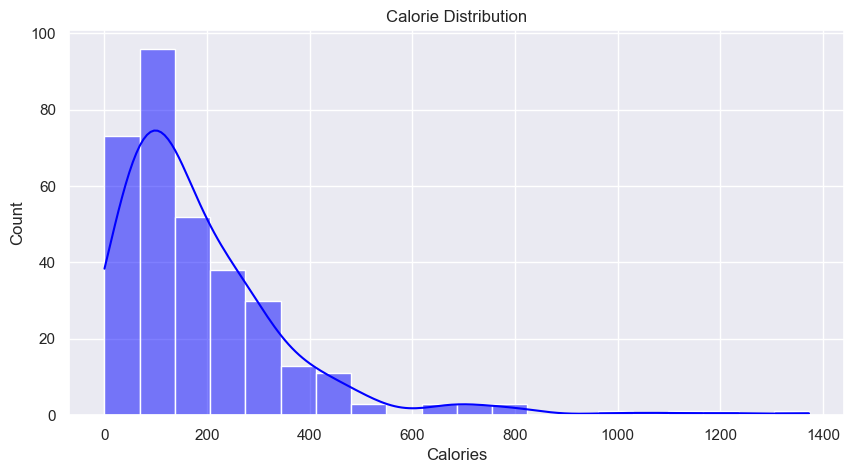

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Calories'], bins=20, kde=True, color='blue')
plt.title('Calorie Distribution')
plt.show()

**Insight:** Most foods in this dataset are within the low-calorie range (under 400), while few items are very high in energy.

### Bivariate Analysis
### Visualization 2: Protein Content by Category

**Reason:** To compare which food groups provide the most protein on average.

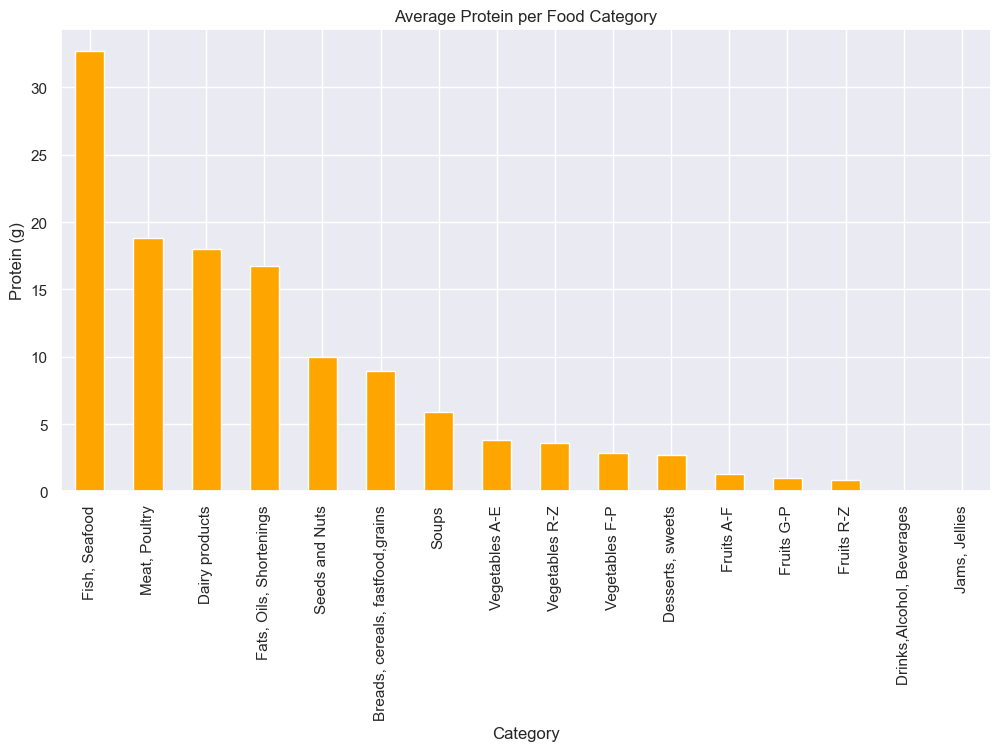

In [11]:
plt.figure(figsize=(12,6))
df.groupby('Category')['Protein'].mean().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title("Average Protein per Food Category")
plt.ylabel("Protein (g)")
plt.show()

**Insight:** As expected, 'Meat, Poultry' and 'Fish, Seafood' have the highest protein levels, while 'Fruits' and 'Vegetables' are at the lower end.

### Multivariate Analysis 
### Visualization 3: Fat vs Calories Correlation

**Reason:** To investigate if higher fat content directly leads to higher calories.

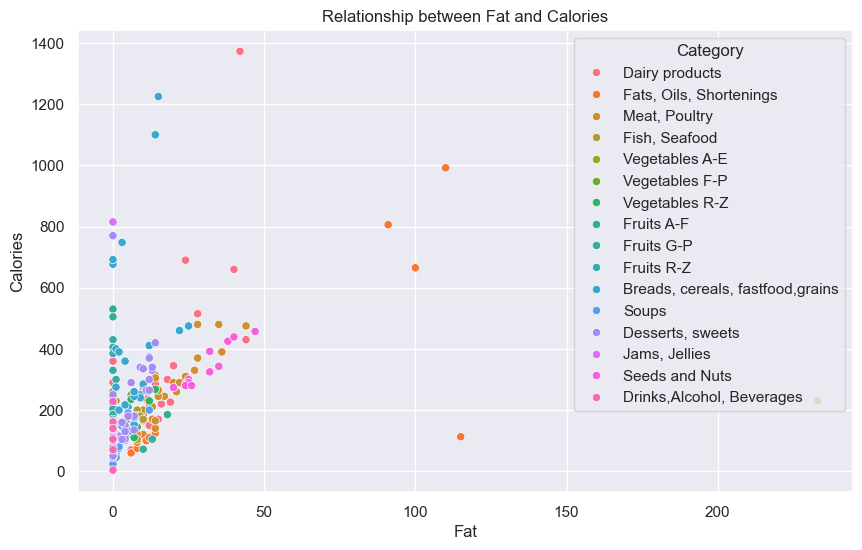

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Fat', y='Calories', data=df, hue='Category')
plt.title("Relationship between Fat and Calories")
plt.show()

**Insight:** There is a clear linear relationship; foods with high fat content consistently show higher total calories.

### Multivariate Analysis
### Visualization 4: Correlation Matrix

**Reason:** To see the correlation coefficients between all nutritional components.

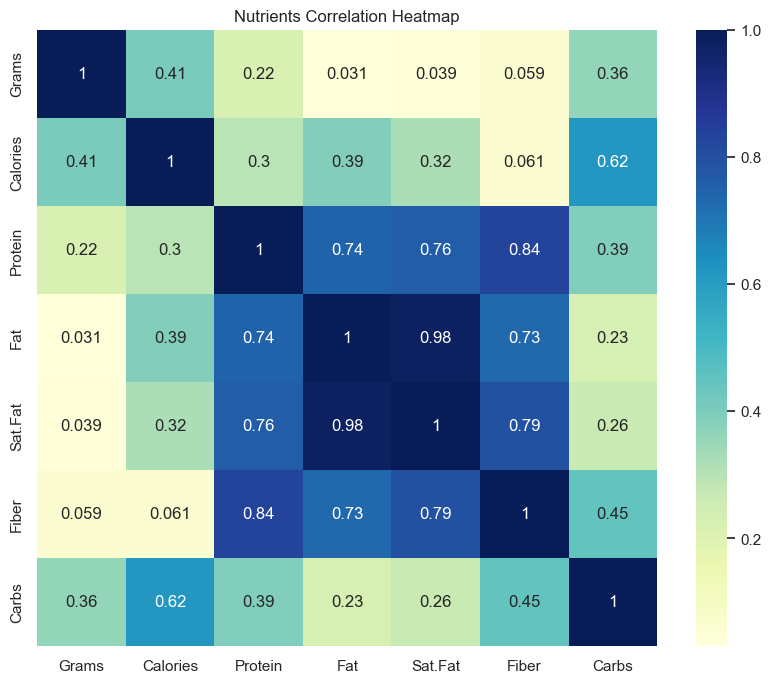

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title("Nutrients Correlation Heatmap")
plt.show()

**Insight:** Calories show the strongest correlation with Fat (0.8+) and Carbs, while Fiber has a very weak correlation with total calories.

### Bivariate Analysis
### Visualization 5: Top 10 High-Fiber Foods (Bar Chart)

**Reason:** To highlight specific "Superfoods" that are high in fiber, which is important for health insights.

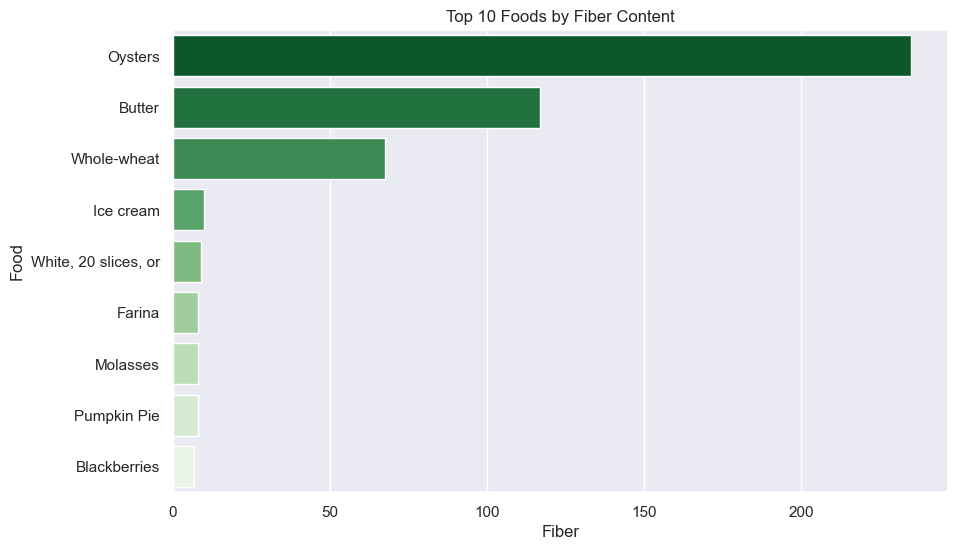

In [19]:
top_fiber = df.nlargest(10, 'Fiber')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_fiber, x='Fiber', y='Food', hue='Food', palette='Greens_r', legend=False)
plt.title('Top 10 Foods by Fiber Content')
plt.show()

**Insight:** Seeds, nuts, and certain legumes dominate the high-fiber list, showing that plant-based fats often come with high fiber benefits.

### Bivariate Analysis
### Visualization 6: Carbohydrates vs. Calories (Regression Plot)

**Reason:** To see how much carbohydrates contribute to the energy value compared to fats.

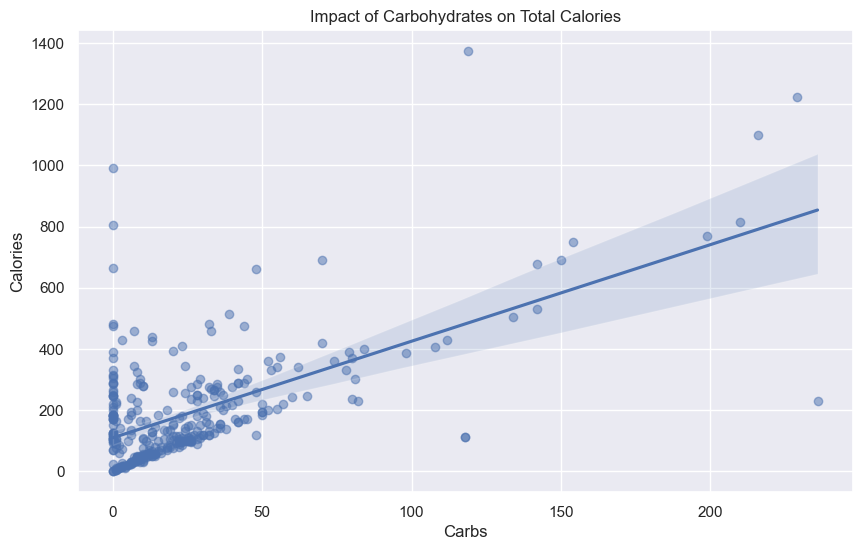

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Carbs', y='Calories', scatter_kws={'alpha':0.5})
plt.title('Impact of Carbohydrates on Total Calories')
plt.show()

**Insight:** While carbs do increase calories, the slope is slightly different from fats, indicating that the dataset contains a mix of high-carb/low-fat and high-carb/high-fat items.

### Univariate Analysis
### Visualization 7: Category Count (Count Plot)

**Reason:** To understand the balance of the dataset and see which food categories are most represented.

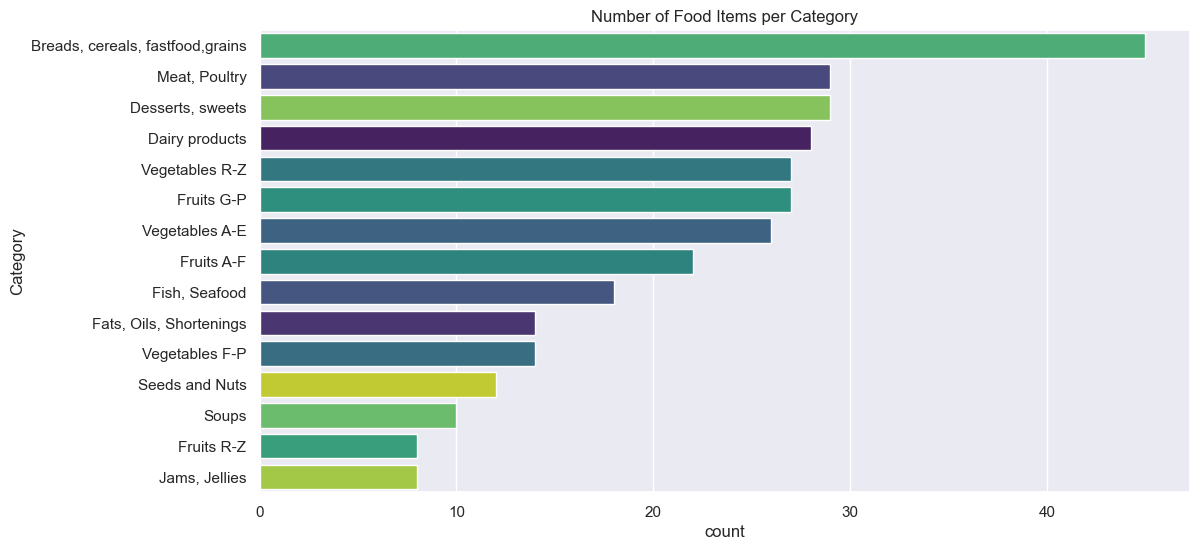

In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(
    y='Category', 
    data=df, 
    order=df['Category'].value_counts().index, 
    hue='Category', 
    palette='viridis', 
    legend=False
)
plt.title('Number of Food Items per Category')
plt.show()

**Insight:** The dataset is well-diversified, but categories like 'Vegetables' and 'Breads' have more entries, meaning the insights are more reliable for these groups.

## Final Conclusion

The Exploratory Data Analysis (EDA) on the Nutrients dataset provided several key insights:
1. **Data Quality:** The initial data required cleaning to handle 'trace' values and formatting issues, which is a crucial step in any ML project.
2. **Nutritional Correlations:** There is a very strong positive correlation between Fat and Calories, while Protein and Fiber vary significantly across categories.
3. **Top Categories:** Meat and Dairy are the primary sources of protein, while Seeds and Nuts are the most calorie-dense items in the dataset.
4.  **Dietary Recommendations:** Based on the visualization, someone looking for high fiber with low calories should focus on specific vegetables and legumes identified in the top-fiber analysis.